In [1]:
import pandas as pd
import matplotlib.pyplot as plt
#load file
df = pd.read_csv(r"C:\CMPINF\Pittsburgh_Trees.csv")
#Remove dud entries
df = df[~df['common_name'].isin([
    'Non-sufficient space', 'Unknown', 'Unknown Shrub',
    'Vacant Site Large', 'Vacant Site Medium',
    'Vacant Site Not Suitable', 'Vacant Site Small'
])]

#print
df

C:\Users\袁子涵\AppData\Local\Temp\ipykernel_12832\1745588189.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\CMPINF\Pittsburgh_Trees.csv")


,_id,id,address_number,street,common_name,scientific_name,height,width,growth_space_length,growth_space_width,...,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude
0,1,754166088,7428.0,MONTICELLO ST,Stump,Stump,0.0,0.0,10.0,2.0,...,Homewood North,9.0,13.0,4.200313e+10,2.0,13.0,5.0,3-17,40.458169,-79.889724
1,2,1946899269,220.0,BALVER AVE,Linden: Littleleaf,Tilia cordata,0.0,0.0,99.0,99.0,...,Oakwood,2.0,28.0,4.200356e+10,5.0,28.0,6.0,1-19,40.429269,-80.067868
2,3,1431517397,2822.0,SIDNEY ST,Maple: Red,Acer rubrum,22.0,6.0,6.0,3.0,...,South Side Flats,3.0,16.0,4.200316e+10,3.0,16.0,3.0,4-24,40.426797,-79.965035
3,4,994063598,608.0,SUISMON ST,Maple: Freeman,Acer x freemanii,25.0,10.0,3.0,3.0,...,East Allegheny,1.0,23.0,4.200356e+10,1.0,23.0,1.0,1-6,40.455503,-79.999276
4,5,1591838573,1135.0,N NEGLEY AVE,Maple: Norway,Acer platanoides,52.0,13.0,99.0,99.0,...,Highland Park,7.0,11.0,4.200311e+10,2.0,11.0,5.0,3-9,40.476667,-79.924106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45704,46384,39047675,499 N LANG AVE,N LANG AVE,Maple: Norway,Acer platanoides,15.0,15.0,NaN,NaN,...,Point Breeze North,9.0,14.0,4.200314e+10,2.0,14.0,4.0,3-14,40.453499,-79.901280
45705,46417,1827907131,NaN,NaN,Maple: Sugar,Acer saccharum,NaN,NaN,NaN,NaN,...,Squirrel Hill North,8.0,14.0,4.200314e+10,3.0,14.0,4.0,2-8,40.443065,-79.934139
45706,46418,1513723611,NaN,NaN,Maple: Sugar,Acer saccharum,NaN,NaN,NaN,NaN,...,Squirrel Hill North,8.0,14.0,4.200314e+10,3.0,14.0,4.0,2-8,40.443010,-79.934095
45707,46419,1830872418,NaN,NaN,Maple: Sugar,Acer saccharum,NaN,NaN,NaN,NaN,...,Squirrel Hill North,8.0,14.0,4.200314e+10,3.0,14.0,4.0,2-8,40.442946,-79.934062


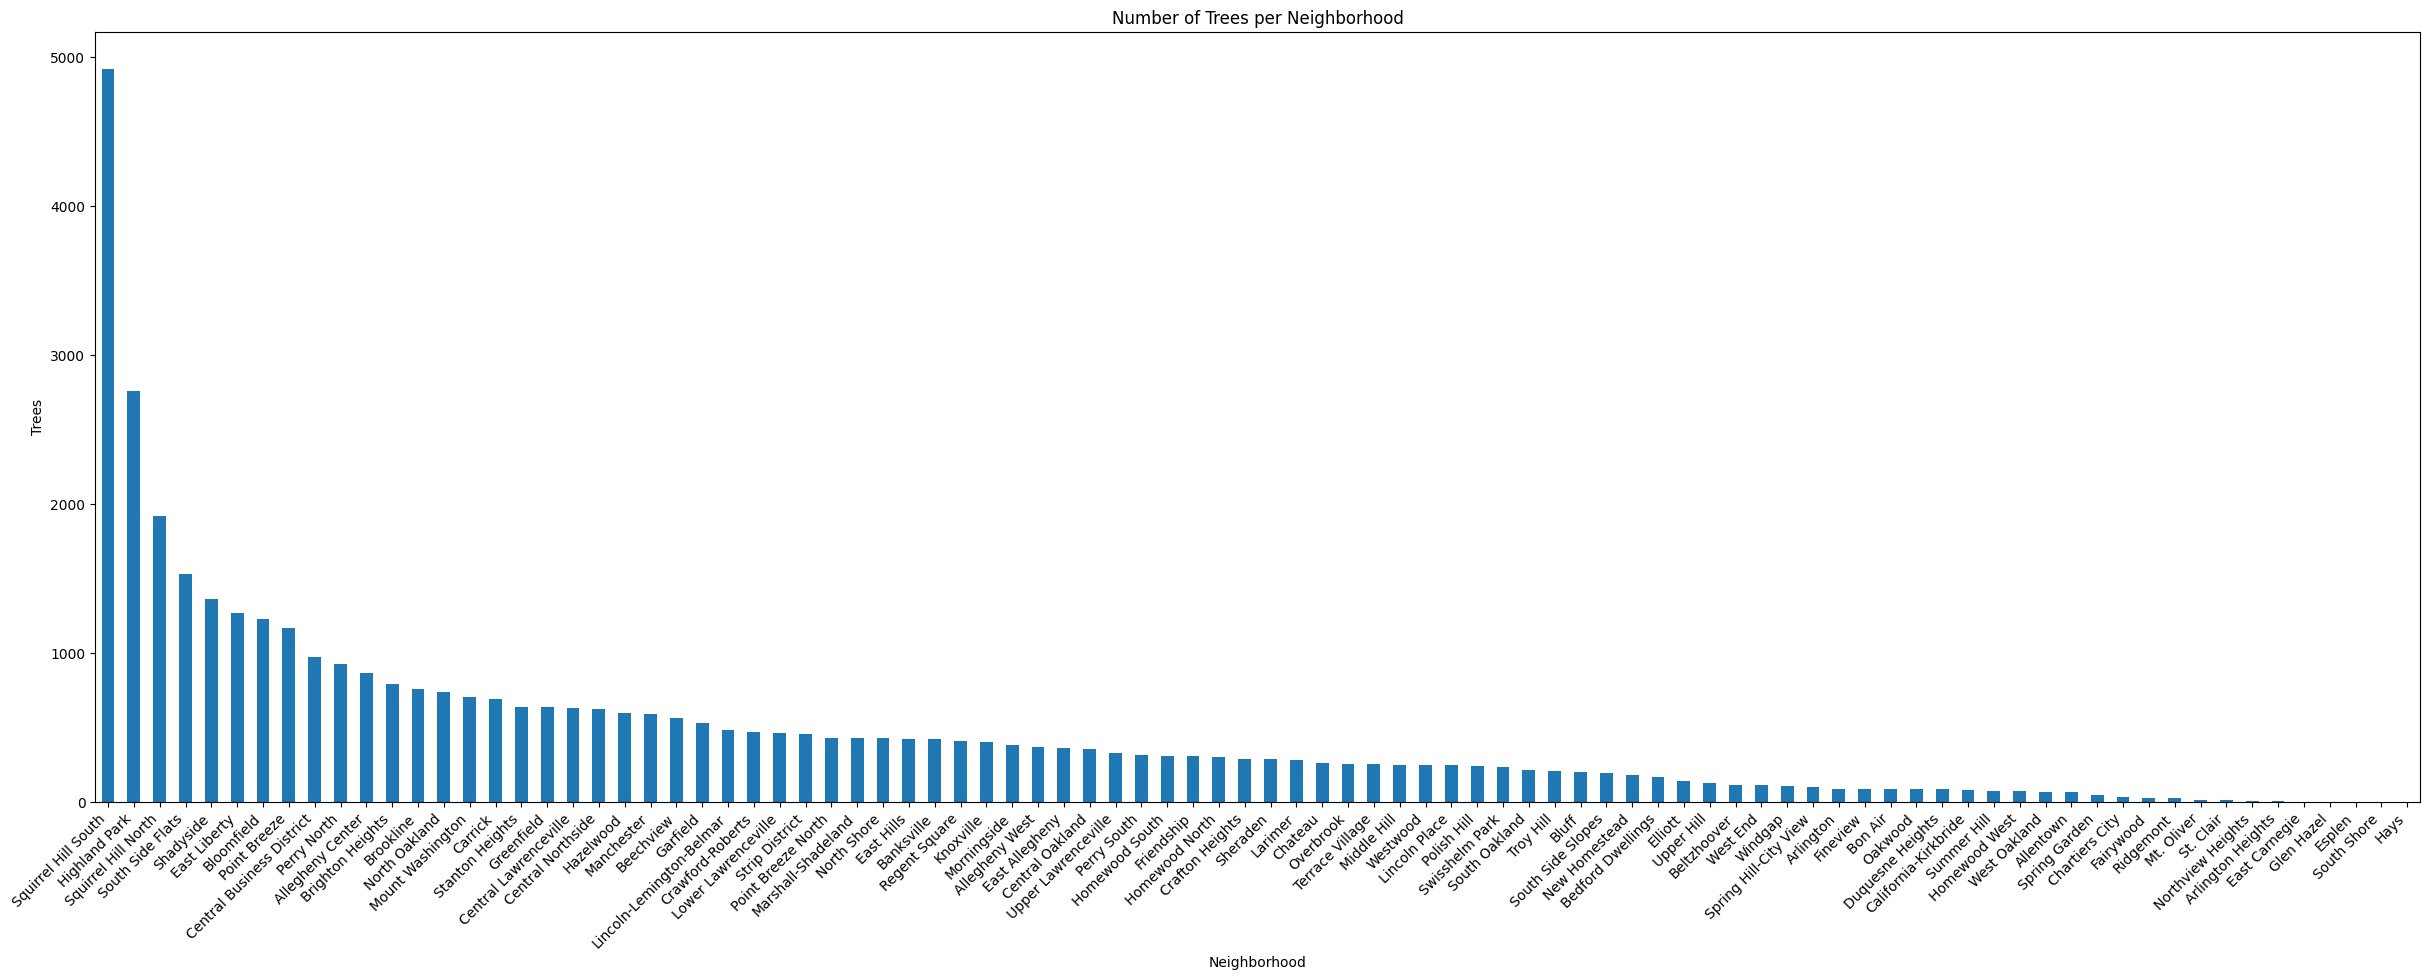

In [2]:
#Plot trees by neighborhood
plt.figure(figsize=(30, 10))
df['neighborhood'].value_counts().plot.bar()
plt.title('Number of Trees per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Trees')
plt.xticks(
    rotation=45,
    ha="right"
)
plt.show()

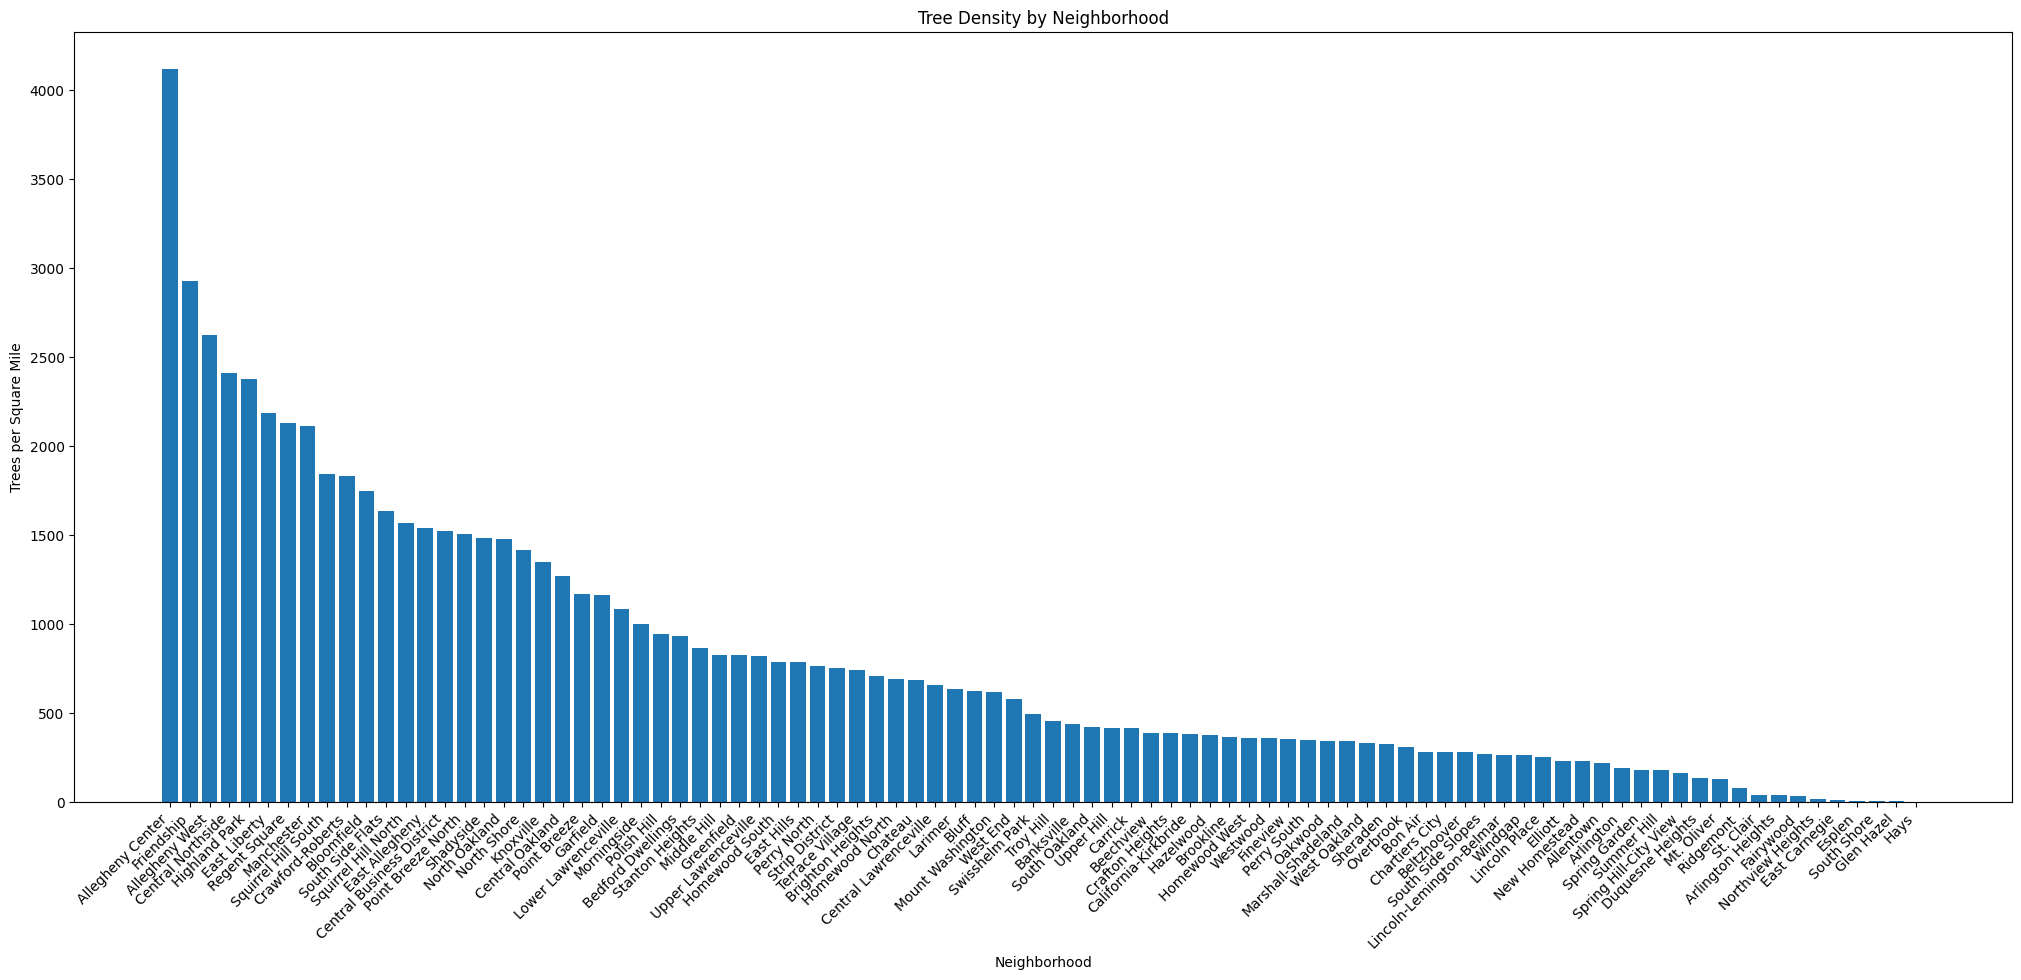

In [3]:
#Chart tree to size ratio
#Neighborhood size taken from https://web.archive.org/web/20070810193148/http://www.city.pittsburgh.pa.us/cp/assets/census/2000_census_pgh_jan06.pdf
neighborhood_df = pd.read_csv(r"C:\CMPINF\neighborhood_size.csv")
#Calculate the ratio of trees/square mile
tree_counts = df['neighborhood'].value_counts()
neighborhood_df['trees'] = neighborhood_df['neighborhood'].map(tree_counts).fillna(0).astype(int)
neighborhood_df['tree_density'] = neighborhood_df['trees'] / neighborhood_df['neighborhood_size'].replace(0, pd.NA)
#Plot
#sort
plot_df = neighborhood_df.sort_values('tree_density', ascending=False)
plt.figure(figsize=(25, 10))
plt.bar(plot_df['neighborhood'], plot_df['tree_density'])
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Trees per Square Mile")
plt.title("Tree Density by Neighborhood")
plt.xticks(
    rotation=45,
    ha="right"
)
plt.show()

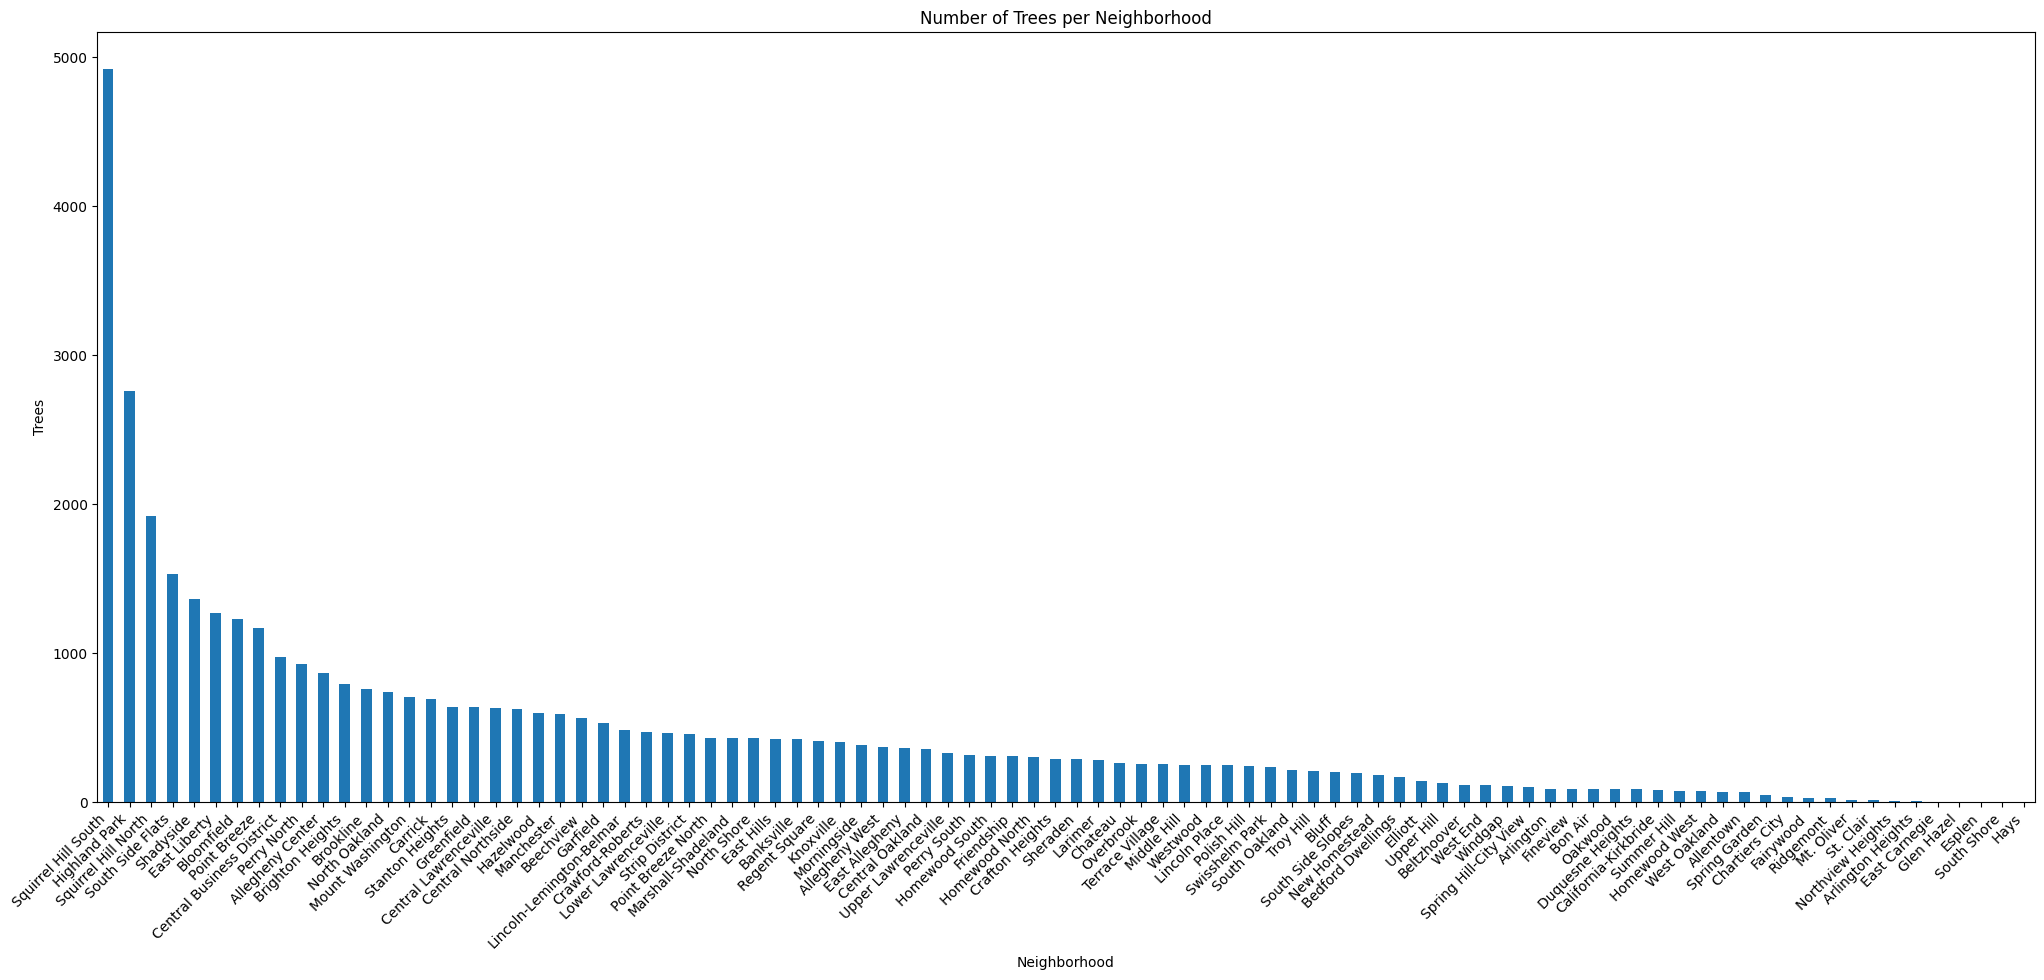

In [4]:
#Plot trees by neighborhood
plt.figure(figsize=(25, 10))
df['neighborhood'].value_counts().plot.bar()
plt.title('Number of Trees per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Trees')
plt.xticks(
    rotation=45,
    ha="right"
)
plt.show()

In [9]:
# normalize density → 0-1
plot_df['tree_score'] = (
    plot_df['tree_density'] - plot_df['tree_density'].min()
) / (
    plot_df['tree_density'].max() - plot_df['tree_density'].min()
)

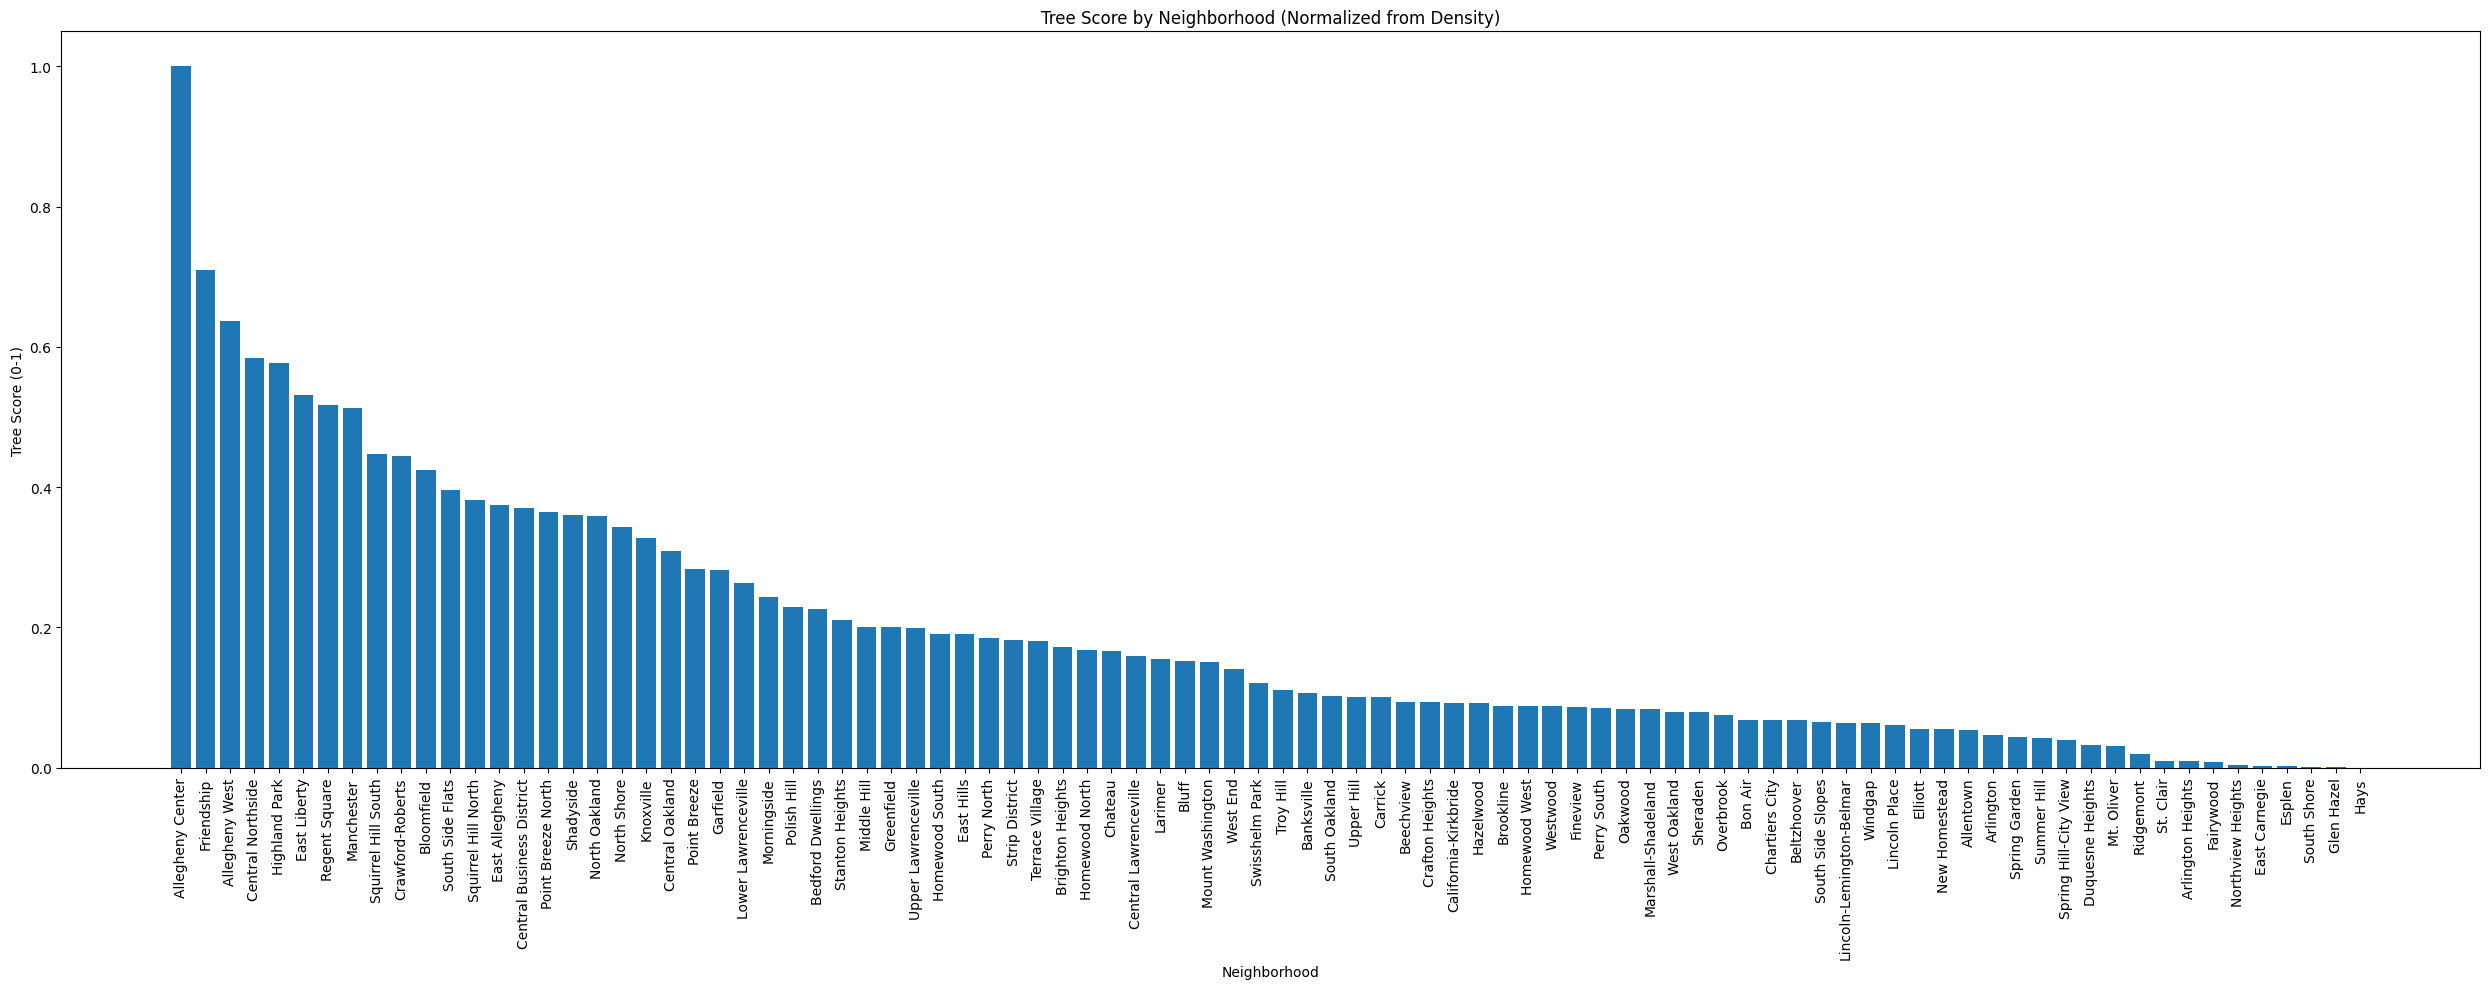

In [10]:
plot_df = plot_df.sort_values('tree_score', ascending=False)

plt.figure(figsize=(25, 10))

plt.bar(plot_df['neighborhood'], plot_df['tree_score'])

plt.xlabel("Neighborhood")
plt.ylabel("Tree Score (0-1)")
plt.title("Tree Score by Neighborhood (Normalized from Density)")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### Tree Metric Analysis

For the tree metric, we first look at how many trees are in each neighborhood. However, we realized that just using the total number of trees is not very significant, because larger neighborhoods will naturally have more trees. To fix this, we calculated tree density (trees per square mile) by combining the tree data with neighborhood size data.Using density makes the comparison more meaningful, since it shows how “green” a neighborhood actually is relative to its size. After that, we normalized the density values to a 0–1 range to create a tree score. This step is important because it allows us to compare and combine this metric with others.From the results, we can see that some neighborhoods have much higher tree density than others, meaning they likely have more green space and a better environment. Overall, using tree density instead of raw counts gives a more accurate representation of livability.
